In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Unzipping the dataset file**

In [21]:
import zipfile
with zipfile.ZipFile('/content/drive/MyDrive/archive.zip') as zip_ref:
  zip_ref.extractall('dataset')

**Importing libraries**

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import tensorflow as tf
import keras
import os
import cv2
import numpy as np
import pandas as pd
import random
from sklearn.model_selection import train_test_split

%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

**Preparing images and labels**

**Splitting data into training and test sets**

**Normalizing the data**

In [22]:
data_dir = "/content/dataset/NEU-DET"
classes = ['crazing', 'inclusion', 'pitted_surface', 'rolled-in_scale', 'patches', 'scratches']
img_size = 256

x, y = [], []

for label, class_name in enumerate(classes):
    folder = os.path.join(data_dir, 'train', 'images', class_name)
    for file in os.listdir(folder):
        img = cv2.imread(os.path.join(folder, file), cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (img_size, img_size))
        x.append(img)
        y.append(label)

for label, class_name in enumerate(classes):
    folder = os.path.join(data_dir, 'validation', 'images', class_name)
    for file in os.listdir(folder):
        img = cv2.imread(os.path.join(folder, file), cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (img_size, img_size))
        x.append(img)
        y.append(label)


x = np.array(x).reshape(-1, img_size, img_size, 1) / 255.0
y = np.array(y)
print(x.shape, y.shape)

(1800, 256, 256, 1) (1800,)




**Check and view Images from each available class**


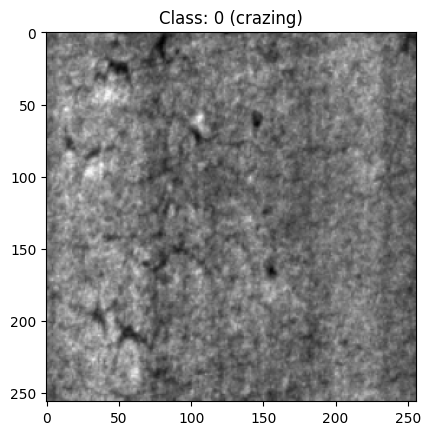

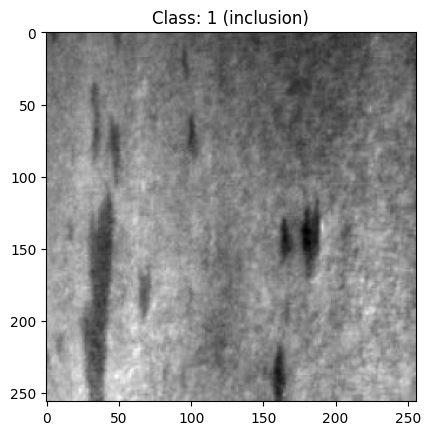

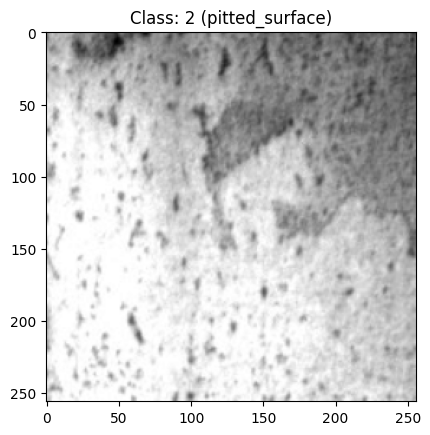

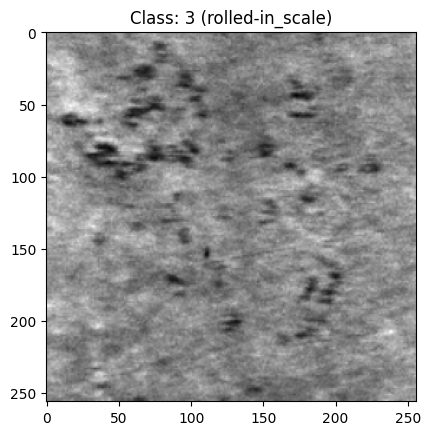

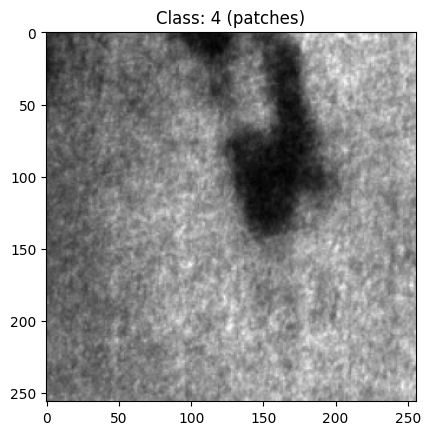

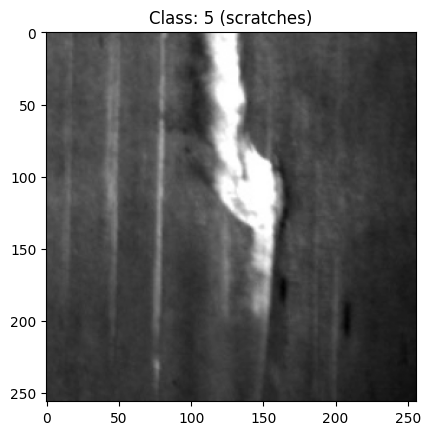

In [23]:
unique_labels = np.unique(y)

for label in unique_labels:
    all_indices_for_label = np.where(y == label)[0]
    random_idx = random.choice(all_indices_for_label)
    plt.imshow(x[random_idx], cmap='gray')
    plt.title(f'Class: {label} ({classes[label]})')
    plt.show()

**Model Checkpoint and Early Stopping Callbacks**

In [24]:
from tensorflow.keras.callbacks import EarlyStopping,ModelCheckpoint

early_stop = EarlyStopping(monitor='val_accuracy', patience=120, restore_best_weights=True)

**Model Definition**

In [25]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [26]:
from sklearn.metrics import accuracy_score,f1_score,precision_score
from tensorflow.keras.models import load_model


model=keras.Sequential()
model.add(keras.layers.Conv2D(136,(2,2),strides=(2,2),input_shape=(256,256,1)))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('relu'))
model.add(keras.layers.MaxPooling2D((2,2)))
model.add(keras.layers.Conv2D(272,(2,2),strides=(2,2)))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('relu'))
model.add(keras.layers.MaxPooling2D((2,2)))
model.add(keras.layers.Conv2D(544,(2,2),strides=(2,2)))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('relu'))
model.add(keras.layers.MaxPooling2D((2,2)))
model.add(keras.layers.Conv2D(1088,(2,2),strides=(2,2)))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('relu'))
model.add(keras.layers.MaxPooling2D((2,2)))

model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(1000,activation='relu'))
model.add(keras.layers.Dense(1000,activation='relu'))
model.add(keras.layers.Dense(1000,activation='relu'))
model.add(keras.layers.Dense(6,activation='softmax'))

total_acc = []
total_f1 = []
total_recall = []
total_precision = []
total_auc = []

best_acc = 0
best_history = None
best_x_test = None
best_y_test = None
best_y_pred = None

for train_idx,test_idx in skf.split(x, y):
  x_train=x[train_idx]
  y_train=y[train_idx]
  x_test=x[test_idx]
  y_test=y[test_idx]

  model.compile(optimizer=tf.optimizers.Adam(learning_rate=0.0001),loss='sparse_categorical_crossentropy',metrics=['accuracy'])
  checkpoint = ModelCheckpoint('best_model.h5', monitor='val_accuracy', save_best_only=True)
  hist=model.fit(x_train,y_train,epochs=200,batch_size=21,validation_data=(x_test,y_test),callbacks=[checkpoint,early_stop])
  model.summary()


  model=load_model('best_model.h5')

  y_pred = model.predict(x_test)
  y_pred = np.argmax(y_pred, axis=1)
  ac=accuracy_score(y_test, y_pred)
  p=precision_score(y_test, y_pred, average='weighted')
  f=f1_score(y_test, y_pred, average='weighted')
  total_acc.append(ac)
  total_f1.append(f)
  total_precision.append(p)

  if ac > best_acc:
    best_acc = ac
    best_history = hist
    best_x_test = x_test
    best_y_test = y_test
    best_y_pred = y_pred
  print(f"accuracy: {ac}\nprecision: {p}\nf1_score: {f}")

Epoch 1/200
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.7259 - loss: 0.8335

69/69 ━━━━━━━━━━━━━━━━━━━━ 16s 133ms/step - accuracy: 0.8104 - loss: 0.5953 - val_accuracy: 0.1667 - val_loss: 2.3902
Epoch 2/200
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.8972 - loss: 0.3141 - val_accuracy: 0.1667 - val_loss: 4.4582
Epoch 3/200
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.9312 - loss: 0.2199 - val_accuracy: 0.1667 - val_loss: 6.3011
Epoch 4/200
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.9174 - loss: 0.2234 - val_accuracy: 0.1667 - val_loss: 5.7801
Epoch 5/200
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - accuracy: 0.9340 - loss: 0.1950 - val_accuracy: 0.1667 - val_loss: 6.4758
Epoch 6/200
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.9518 - loss: 0.1319

69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - accuracy: 0.9438 - loss: 0.1661 - val_accuracy: 0.1722 - val_loss: 5.7822
Epoch 7/200
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.9561 - loss: 0.1352

69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.9535 - loss: 0.1400 - val_accuracy: 0.1917 - val_loss: 6.1654
Epoch 8/200
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.9431 - loss: 0.1690

69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.9389 - loss: 0.1742 - val_accuracy: 0.3278 - val_loss: 3.7226
Epoch 9/200
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.9597 - loss: 0.1278

...

 Total params: 18,637,076 (71.09 MB)

 Trainable params: 6,210,998 (23.69 MB)

 Non-trainable params: 4,080 (15.94 KB)

 Optimizer params: 12,421,998 (47.39 MB)

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step
accuracy: 1.0
precision: 1.0
f1_score: 1.0




**Model Evaluation**


In [27]:
print(total_acc)
print(f"average accuracy: {np.mean(total_acc)}")
print()
print(total_f1)
print(f"average f1_score: {np.mean(total_f1)}")
print()
print(total_precision)
print(f"average precision: {np.mean(total_precision)}")

[0.9944444444444445, 1.0, 1.0, 1.0, 1.0]
average accuracy: 0.9988888888888889

[0.9944442515298131, 1.0, 1.0, 1.0, 1.0]
average f1_score: 0.9988888503059627

[0.9944899817850639, 1.0, 1.0, 1.0, 1.0]
average precision: 0.9988979963570127


**Visualization**

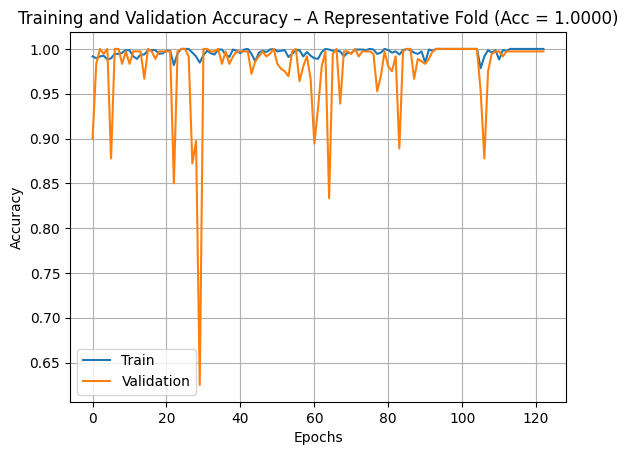

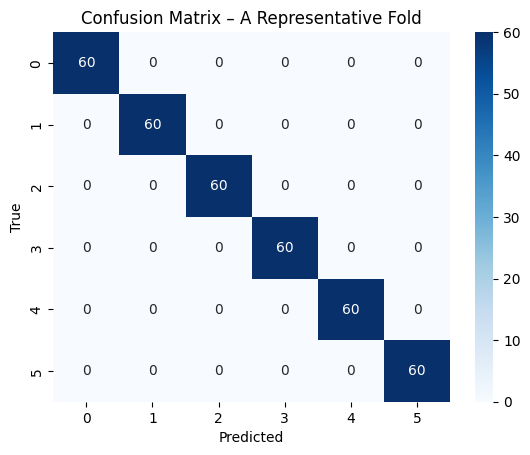

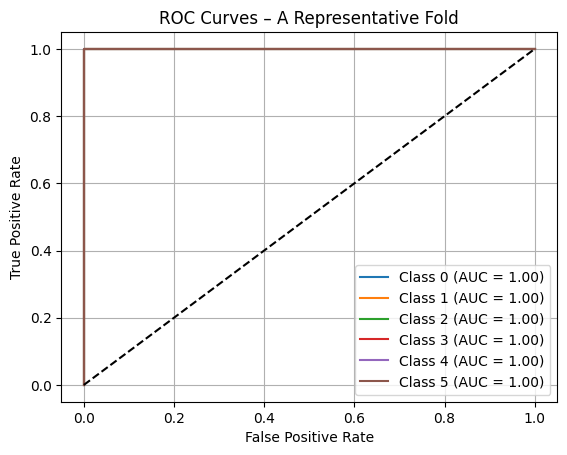

In [31]:
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
from google.colab import files


#Accuracy
plt.figure()
plt.plot(best_history.history['accuracy'], label='Train')
plt.plot(best_history.history['val_accuracy'], label='Validation')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.title(f'Training and Validation Accuracy – A Representative Fold (Acc = {best_acc:.4f})')
plt.show()

#confusion_matrix
cm = confusion_matrix(best_y_test, best_y_pred)
plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix – A Representative Fold')
plt.show()

#ROC Curves
y_test_onehot = label_binarize(best_y_test, classes=[0,1,2,3,4,5])
y_pred_onehot = label_binarize(best_y_pred, classes=[0,1,2,3,4,5])
plt.figure()
for i in range(6):
     fpr, tpr, _ = roc_curve(y_test_onehot[:, i], y_pred_onehot[:, i])
     plt.plot(fpr, tpr, label=f'Class {i} (AUC = {auc(fpr, tpr):.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.title('ROC Curves – A Representative Fold')
plt.grid(True)
plt.show()